In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from dotenv import load_dotenv
import os
import seaborn as sns
load_dotenv()

True

IMPORT THE DATA

In [3]:
sales = pd.read_csv(os.getenv("CLEAN_DATA_PATH") + "/sales_train_cnt_0.csv")

PREP WORK


In [ ]:
cat_cols = ["shop_id", "item_id", "item_category_id", "month_block_num"]
numeric_cols = ["item_price", "item_cnt_month"]
target_col = "item_cnt_month"

In [ ]:
def cramer_v(col1: pd.Series, col2:pd.Series) -> float:
    """
    Returns the Cramer V correlation between two nominal variables
    """
    # Create a contingency table
    contingency_table = pd.crosstab(col1, col2)
    chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Calculate Cramer's V
    n = contingency_table.sum().sum()
    phi2 = chi2_statistic / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    k_corr = k - (k - 1) * (k - 2) / (n - 1)
    r_corr = r - (r - 1) * (r - 2) / (n - 1)
    v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))
    
    return v

In [ ]:
def get_nominal_var_corr_matrix() -> pd.DataFrame:
    """
    Returns the Cramer V correlation matrix of all nominal variables
    in sales dataframe
    """
    # empty correlation matrix dataframe
    corr_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
    num_cat_vars = len(cat_cols)
    corr_values = {}
    for k in range(num_cat_vars):
        corr_values[k] = []

    for i in range(num_cat_vars):
        for j in range(i, num_cat_vars):
            vari, varj = [cat_cols[i], cat_cols[j]]
            # matrix diagonal case (in correlation matrix)
            # m at row i and column i is ~1.00
            if (i == j):
                corr_values.get(i).append(cramer_v(sales[vari], sales[varj])) 
            # we haven't calculated corr(vari, varj)
            # when i > j, value at m row i and column j has been
            #appended in prior iteration
            elif (i < j):
                corr_coef = cramer_v(sales[varj], sales[vari])
                #store correlation coefficient  in dict
                corr_values.get(i).append(corr_coef)
                corr_values.get(j).append(corr_coef)
    
    for k in range(num_cat_vars):
        corr_matrix[cat_cols[k]] = corr_values.get(k)
    return corr_matrix

In [7]:

def get_cat_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Turns the the values of columns that are categorical variables 
    from integer to string
    """
    new_df = df[numeric_cols]
    for column in cat_cols:
        new_df[column] = df[column].astype(str)
    return new_df

In [8]:
sales = get_cat_columns(sales)

Basic Information

In [9]:
sales.shape

(2935843, 6)

In [40]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 2935843 entries, 0 to 2935842
Data columns (total 6 columns):
 #   Column            Dtype  
---  ------            -----  
 0   item_price        float64
 1   item_cnt_month    float64
 2   shop_id           str    
 3   item_id           str    
 4   item_category_id  str    
 5   month_block_num   str    
dtypes: float64(2), str(4)
memory usage: 134.4 MB


SUMMARY STATISTICS

In [10]:
print("Summary for categorical variables")
sales[cat_cols].describe()

Summary for categorical variables


,shop_id,item_id,item_category_id,month_block_num
count,2935843,2935843,2935843,2935843
unique,60,21807,84,34
top,31,20949,40,11
freq,235636,31340,564651,143246


In [ ]:
print("Summary for numerical variables")
sales[numeric_cols].describe()

SUmmary for numerical variables


,item_price,item_cnt_month
count,2.935843e+06,2.935843e+06
mean,8.908535e+02,7.410409e+00
std,1.729801e+03,3.033649e+01
min,7.000000e-02,0.000000e+00
25%,2.490000e+02,1.000000e+00
50%,3.990000e+02,2.000000e+00
75%,9.990000e+02,5.000000e+00
max,3.079800e+05,2.253000e+03


CORRELATION MATRICES

In [17]:
#correlation matrix of categorical variables
cat_corr_matrix = get_nominal_var_corr_matrix()

PLOTTING GRAPHS

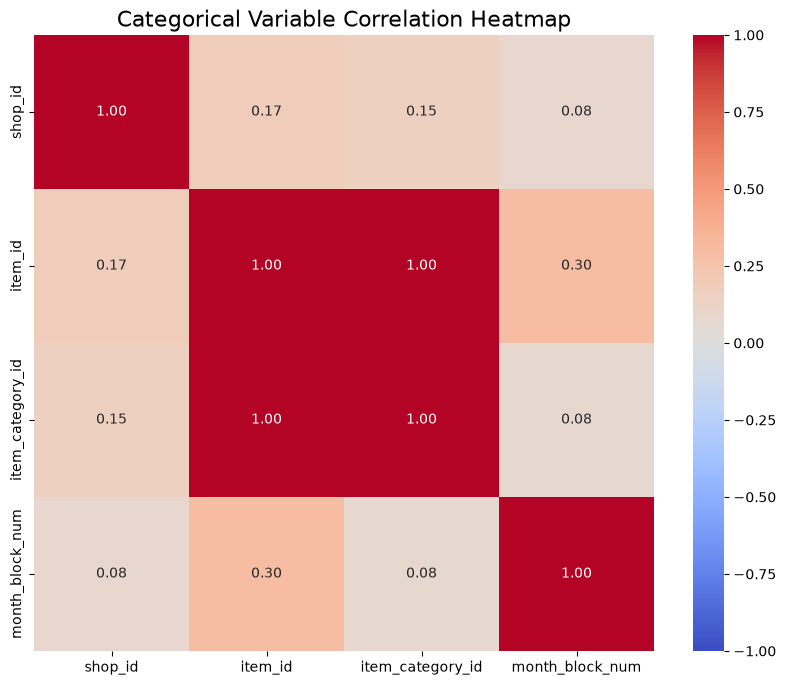

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(cat_corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Categorical Variable Correlation Heatmap", fontsize=16)
plt.show()

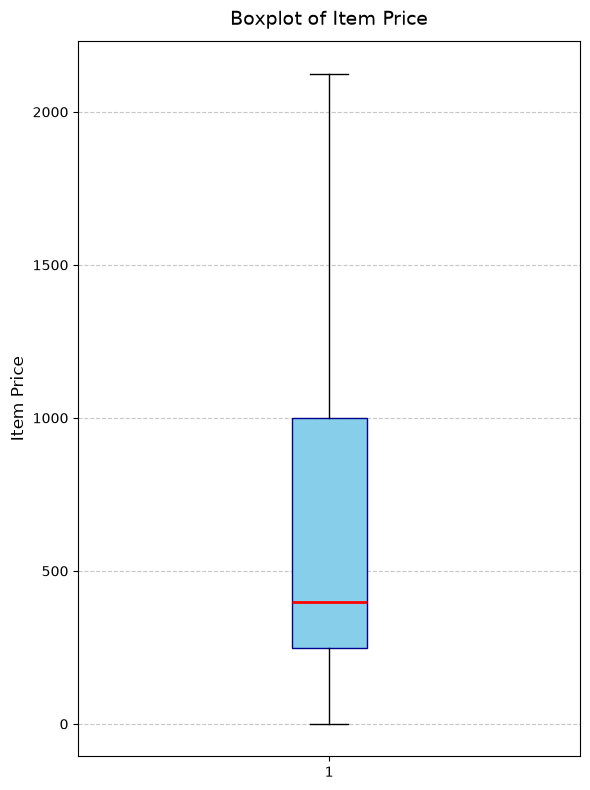

In [26]:
import matplotlib.pyplot as plt

# Create boxplot of item_price
plt.figure(figsize=(6, 8))
plt.boxplot(
    sales['item_price'],
    orientation='vertical',
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='darkblue'),
    medianprops=dict(color='red', linewidth=2),
    showfliers=False
)
plt.title('Boxplot of Item Price', fontsize=14, pad=12)
plt.ylabel('Item Price', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

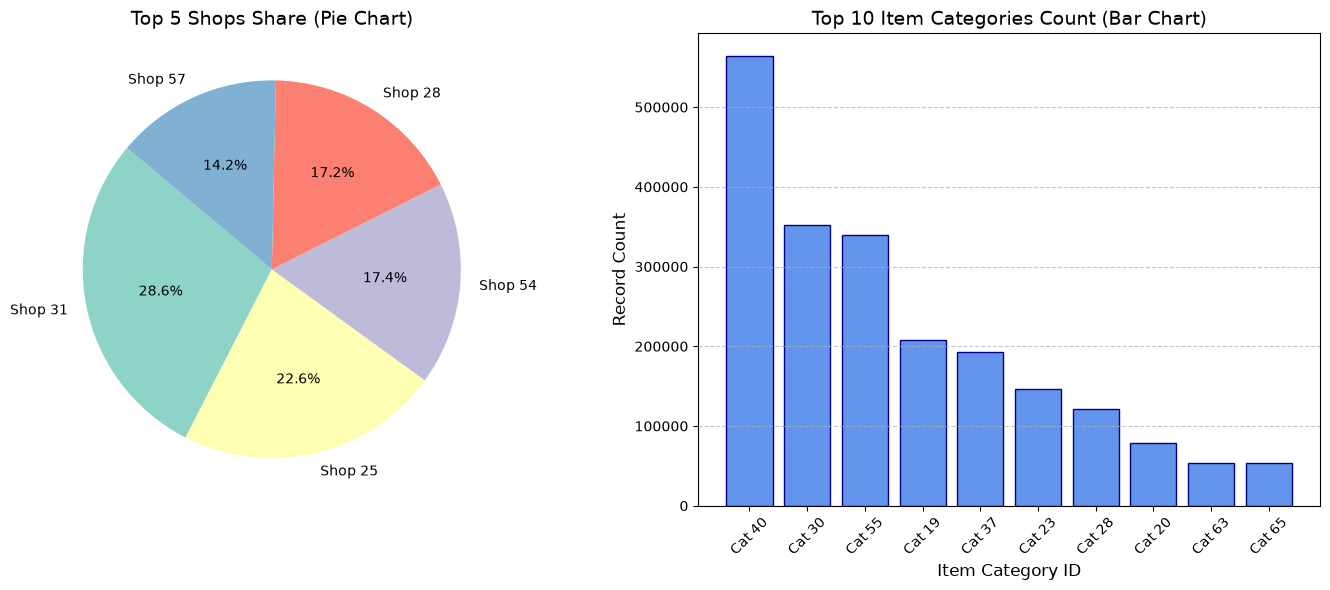

In [29]:
import matplotlib.pyplot as plt

# Create a figure with a Pie Chart and a Bar Chart side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Pie Chart - Top 5 Shops Share
top_shops = sales['shop_id'].value_counts().head(5)
axes[0].pie(
    top_shops,
    labels=[f'Shop {s}' for s in top_shops.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors[:len(top_shops)]
)
axes[0].set_title('Top 5 Shops Share (Pie Chart)', fontsize=14)

# 2. Bar Chart - Top 10 Item Categories Count
top_cats = sales['item_category_id'].value_counts().head(10)
axes[1].bar(
    [f'Cat {c}' for c in top_cats.index],
    top_cats.values,
    color='cornflowerblue',
    edgecolor='navy'
)
axes[1].set_title('Top 10 Item Categories Count (Bar Chart)', fontsize=14)
axes[1].set_xlabel('Item Category ID', fontsize=12)
axes[1].set_ylabel('Record Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
